In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("Libraries loaded")

Libraries loaded


In [2]:
raw_path = "../data/raw/online_retail_II.csv"

df= pd.read_csv(raw_path)

print("Combined shape:", df.shape)
df.head()

Combined shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nPercentage missing (Customer ID):")
print(round(df['Customer ID'].isnull().sum() / len(df) * 100, 2), "%")

Missing values per column:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Percentage missing (Customer ID):
22.77 %


In [6]:
df_clean = df.dropna(subset=['Customer ID']).copy()
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)

print("Shape after dropping missing Customer IDs:", df_clean.shape)
print("Rows removed:", df.shape[0] - df_clean.shape[0])

Shape after dropping missing Customer IDs: (824364, 8)
Rows removed: 243007


In [7]:
df_clean['Invoice'] = df_clean['Invoice'].astype(str)

cancelled_count = df_clean['Invoice'].str.startswith('C').sum()
print("Cancelled invoice rows found:", cancelled_count)

df_clean = df_clean[~df_clean['Invoice'].str.startswith('C')]

print("Shape after removing cancellations:", df_clean.shape)

Cancelled invoice rows found: 18744
Shape after removing cancellations: (805620, 8)


In [8]:
before = df_clean.shape[0]

df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]

after = df_clean.shape[0]
print(f"Removed {before - after} rows with non-positive Quantity or Price")
print("Final clean shape:", df_clean.shape)

Removed 71 rows with non-positive Quantity or Price
Final clean shape: (805549, 8)


In [9]:
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

df_clean[['Invoice', 'Quantity', 'Price', 'TotalPrice']].head()

,Invoice,Quantity,Price,TotalPrice
0,489434,12,6.95,83.4
1,489434,12,6.75,81.0
2,489434,12,6.75,81.0
3,489434,48,2.10,100.8
4,489434,24,1.25,30.0


In [10]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

print("Earliest transaction:", df_clean['InvoiceDate'].min())
print("Latest transaction:", df_clean['InvoiceDate'].max())

Earliest transaction: 2009-12-01 07:45:00
Latest transaction: 2011-12-09 12:50:00


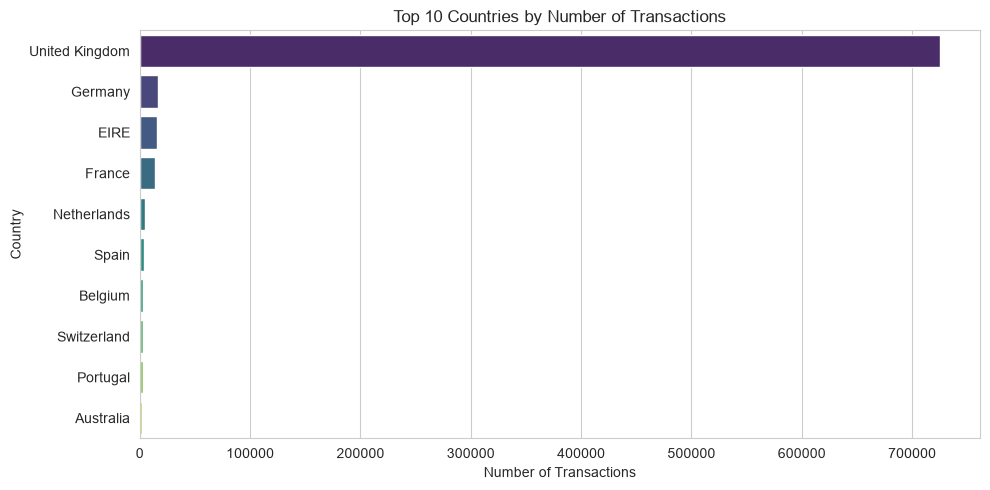

In [15]:
top_countries = df_clean['Country'].value_counts().head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,
    palette='viridis',
    legend=False
)

plt.title('Top 10 Countries by Number of Transactions')
plt.xlabel('Number of Transactions')
plt.ylabel('Country')
plt.tight_layout()

plt.savefig('../images/top_countries.png', dpi=150)

plt.show()

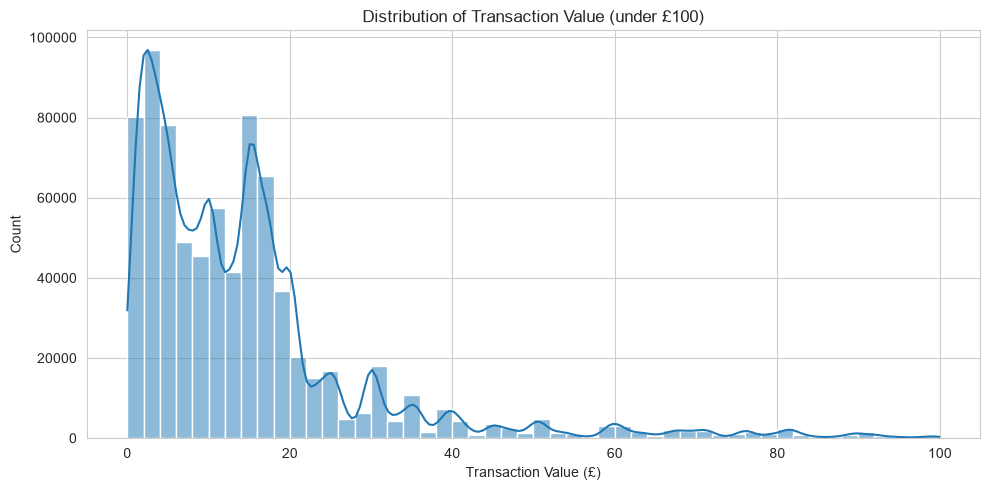

In [16]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean[df_clean['TotalPrice'] < 100]['TotalPrice'],
    bins=50,
    kde=True
)

plt.title('Distribution of Transaction Value (under £100)')
plt.xlabel('Transaction Value (£)')
plt.tight_layout()

plt.savefig('../images/transaction_value_distribution.png', dpi=150)

plt.show()

In [17]:
print("Unique customers:", df_clean['Customer ID'].nunique())
print("Unique invoices:", df_clean['Invoice'].nunique())
print("Unique products (StockCode):", df_clean['StockCode'].nunique())
print("Unique countries:", df_clean['Country'].nunique())
print("Total revenue: £{:,.2f}".format(df_clean['TotalPrice'].sum()))

Unique customers: 5878
Unique invoices: 36969
Unique products (StockCode): 4631
Unique countries: 41
Total revenue: £17,743,429.18


In [18]:
output_path = "../data/processed/cleaned_transactions.csv"

df_clean.to_csv(output_path, index=False)

print(f"Saved cleaned data to {output_path}")
print("Final shape:", df_clean.shape)

Saved cleaned data to ../data/processed/cleaned_transactions.csv
Final shape: (805549, 9)
